# Álgebra Linear

Notebook gerado a partir de `aulas.py` e `lecture1.py`.

## SETUP — rode esta célula primeiro: imports e funções-ajuda


In [2]:
%matplotlib inline
# =============================================================================
#  ÁLGEBRA LINEAR PARA MACHINE LEARNING — do átomo à regressão e ao PCA
# =============================================================================
#
#  Este script percorre, NA ORDEM EM QUE VOCÊ ESTUDOU, cada conceito de
#  álgebra linear que a gente fechou — e mostra, rodando, que eles não são
#  peças soltas: cada um USA o anterior, e no fim tudo desemboca em duas
#  ferramentas centrais de ciência de dados (regressão linear e PCA).
#
#  Como ler: rode o arquivo inteiro (▶ no VSCode) e acompanhe a saída no
#  terminal seção por seção. Cada bloco imprime o "aha" que liga o conceito
#  ao seguinte. Leia os comentários — eles são a aula; o código é a prova.
#
#  Único requisito: numpy.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Deixa a impressão de números mais limpa (3 casas, sem notação científica).
np.set_printoptions(precision=3, suppress=True)


def secao(titulo):
    """Só um separador visual pra organizar a saída no terminal."""
    print("\n" + "=" * 70)
    print(titulo)
    print("=" * 70)




In [3]:
# =============================================================================
#  1) TRANSFORMAÇÃO LINEAR
#     Ideia: uma matriz É uma transformação do espaço. As COLUNAS da matriz
#     são o destino dos vetores da base (para onde î e ĵ vão parar).
# =============================================================================
secao("1) TRANSFORMAÇÃO LINEAR — a matriz é uma transformação; colunas = destino de î e ĵ")

# A base padrão do plano: î aponta pra direita, ĵ aponta pra cima.
i = np.array([1, 0])
j = np.array([0, 1])

# Uma transformação A qualquer. LEIA AS COLUNAS:
#   - 1ª coluna (2,1) = para onde î vai parar.
#   - 2ª coluna (0,3) = para onde ĵ vai parar.
A = np.array([[2, 0],
              [1, 3]])

print("Matriz A =\n", A)
print("A leva î ->", A @ i, "  (é a 1ª coluna de A)")
print("A leva ĵ ->", A @ j, "  (é a 2ª coluna de A)")

# Qualquer outro vetor 'pega carona' nisso: v = 2î + 1ĵ, então
# A(v) = 2*(destino de î) + 1*(destino de ĵ). A matriz só precisa saber
# para onde a base vai — o resto é combinação linear.
v = np.array([2, 1])
print("v =", v, "  ->  A@v =", A @ v,
      "  (= 2*coluna1 + 1*coluna2 =", 2 * A[:, 0] + 1 * A[:, 1], ")")





1) TRANSFORMAÇÃO LINEAR — a matriz é uma transformação; colunas = destino de î e ĵ
Matriz A =
 [[2 0]
 [1 3]]
A leva î -> [2 1]   (é a 1ª coluna de A)
A leva ĵ -> [0 3]   (é a 2ª coluna de A)
v = [2 1]   ->  A@v = [4 5]   (= 2*coluna1 + 1*coluna2 = [4 5] )


### Gráfico — transformação linear


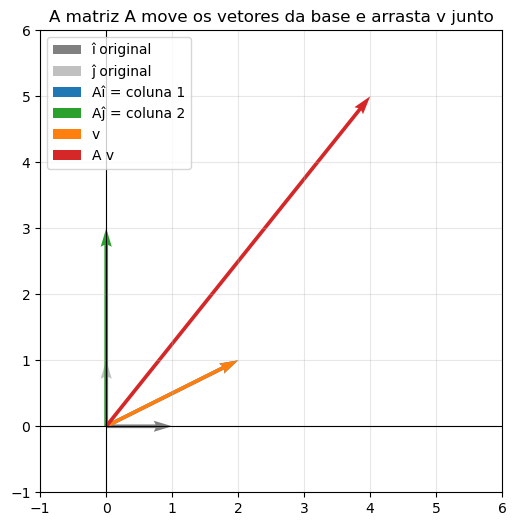

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

def seta(ax, vetor, cor, nome, estilo='-'):
    ax.quiver(0, 0, vetor[0], vetor[1], angles='xy', scale_units='xy', scale=1,
              color=cor, label=nome, width=0.008, linestyle=estilo)

seta(ax, i, 'gray', 'î original')
seta(ax, j, 'silver', 'ĵ original')
seta(ax, A @ i, 'tab:blue', 'Aî = coluna 1')
seta(ax, A @ j, 'tab:green', 'Aĵ = coluna 2')
seta(ax, v, 'tab:orange', 'v')
seta(ax, A @ v, 'tab:red', 'A v')

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.set_title('A matriz A move os vetores da base e arrasta v junto')
plt.show()


In [4]:
# =============================================================================
#  2) MULTIPLICAÇÃO DE MATRIZES = COMPOSIÇÃO DE TRANSFORMAÇÕES
#     Ideia: AB significa "aplica B primeiro, depois A" (lê-se da DIREITA
#     pra ESQUERDA, como f(g(x))). Por isso NÃO é comutativa: a ordem importa.
# =============================================================================
secao("2) MULTIPLICAÇÃO = COMPOSIÇÃO — direita->esquerda, e por isso NÃO comuta")

B = np.array([[1, 2],
              [0, 1]])   # um cisalhamento (shear)

AB = A @ B   # aplica B primeiro, depois A
BA = B @ A   # aplica A primeiro, depois B

print("A@B =\n", AB)
print("B@A =\n", BA)
print("A@B == B@A ?", np.array_equal(AB, BA),
      "  -> ordem importa (não-comutativa), igual a f(g(x)) != g(f(x))")

# Prova de que AB é mesmo 'B primeiro, depois A' num vetor:
print("A@(B@v) =", A @ (B @ v), " deve ser igual a (A@B)@v =", AB @ v)





2) MULTIPLICAÇÃO = COMPOSIÇÃO — direita->esquerda, e por isso NÃO comuta
A@B =
 [[2 4]
 [1 5]]
B@A =
 [[4 6]
 [1 3]]
A@B == B@A ? False   -> ordem importa (não-comutativa), igual a f(g(x)) != g(f(x))
A@(B@v) = [8 7]  deve ser igual a (A@B)@v = [8 7]


In [5]:
# =============================================================================
#  3) DETERMINANTE — fator de escala de ÁREA (orientada). det = 0 => COLAPSO.
#     Ideia: o det diz quanto a transformação amplia área. Sinal = orientação.
#     det = 0 significa que o espaço foi esmagado numa dimensão menor.
# =============================================================================
secao("3) DETERMINANTE — escala de área; det = 0 significa colapso")

print("det(A) =", round(np.linalg.det(A), 3),
      "  -> A amplia áreas por esse fator (sinal = orientação)")

# Uma matriz que COLAPSA o plano numa reta (as duas colunas são paralelas:
# (2,4) é o dobro de (1,2)). Ela esmaga tudo numa única direção.
C = np.array([[1, 2],
              [2, 4]])
print("C =\n", C)
print("det(C) =", round(np.linalg.det(C), 3),
      "  -> ZERO: C esmagou o plano numa reta (perdeu uma dimensão)")





3) DETERMINANTE — escala de área; det = 0 significa colapso
det(A) = 6.0   -> A amplia áreas por esse fator (sinal = orientação)
C =
 [[1 2]
 [2 4]]
det(C) = 0.0   -> ZERO: C esmagou o plano numa reta (perdeu uma dimensão)


### Gráfico — área e colapso


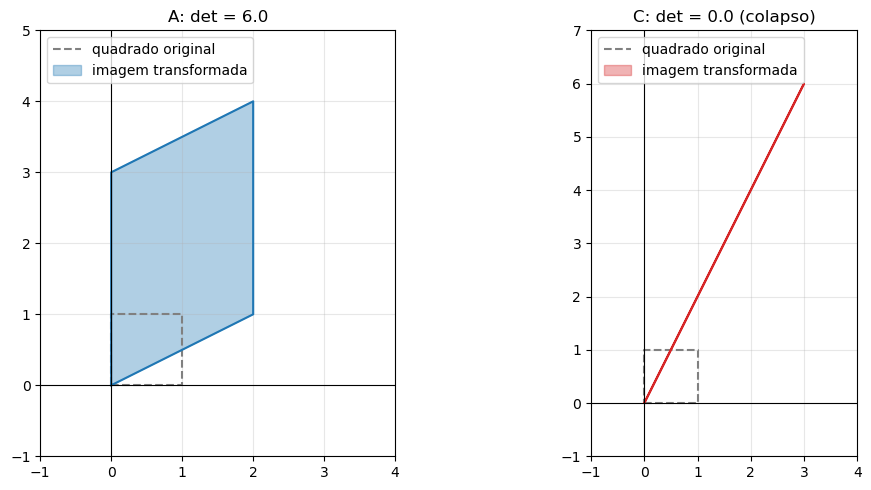

In [6]:
quadrado = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float)

def desenha_area_transformada(ax, M, titulo, cor):
    transformado = quadrado @ M.T
    ax.plot(quadrado[:, 0], quadrado[:, 1], '--', color='gray', label='quadrado original')
    ax.fill(transformado[:, 0], transformado[:, 1], color=cor, alpha=0.35, label='imagem transformada')
    ax.plot(transformado[:, 0], transformado[:, 1], color=cor)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    ax.set_title(titulo)
    ax.legend(loc='upper left')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
desenha_area_transformada(axes[0], A, f'A: det = {np.linalg.det(A):.1f}', 'tab:blue')
desenha_area_transformada(axes[1], C, f'C: det = {np.linalg.det(C):.1f} (colapso)', 'tab:red')
axes[0].set_xlim(-1, 4); axes[0].set_ylim(-1, 5)
axes[1].set_xlim(-1, 4); axes[1].set_ylim(-1, 7)
plt.tight_layout()
plt.show()


In [7]:
# =============================================================================
#  4) POSTO e ESPAÇO-COLUNA — e o TRIÂNGULO com determinante e invertibilidade
#     Ideia: posto = dimensão do espaço-coluna (quantas direções independentes
#     sobrevivem). O triângulo de ferro:
#         posto cheio  <=>  det != 0  <=>  invertível
# =============================================================================
secao("4) POSTO e ESPAÇO-COLUNA — posto cheio <=> det != 0 <=> invertível")

print("posto(A) =", np.linalg.matrix_rank(A),
      " (2 = cheio: nenhuma direção colapsou)")
print("posto(C) =", np.linalg.matrix_rank(C),
      " (1 = deficiente: C esmagou tudo numa reta)")

print("\nO triângulo em ação:")
for nome, M in [("A", A), ("C", C)]:
    r = np.linalg.matrix_rank(M)
    d = np.linalg.det(M)
    cheio = (r == M.shape[0])
    print(f"  {nome}: posto={r}, det={d:+.1f}  ->  posto cheio? {cheio}  ->  "
          f"invertível? {cheio}  (as três afirmações andam JUNTAS)")





4) POSTO e ESPAÇO-COLUNA — posto cheio <=> det != 0 <=> invertível
posto(A) = 2  (2 = cheio: nenhuma direção colapsou)
posto(C) = 1  (1 = deficiente: C esmagou tudo numa reta)

O triângulo em ação:
  A: posto=2, det=+6.0  ->  posto cheio? True  ->  invertível? True  (as três afirmações andam JUNTAS)
  C: posto=1, det=+0.0  ->  posto cheio? False  ->  invertível? False  (as três afirmações andam JUNTAS)


In [8]:
# =============================================================================
#  5) INVERSA — DESFAZ a transformação. Existe só se det != 0.
#     Ideia: se A leva x -> v, então A⁻¹ leva v -> x. A⁻¹A = I ("não faça nada").
#     ATENÇÃO: inversa DESFAZ (diferente da transposta, que só ESPELHA).
# =============================================================================
secao("5) INVERSA — desfaz a transformação (x = A⁻¹v); só existe se det != 0")

A_inv = np.linalg.inv(A)
print("A⁻¹ =\n", A_inv)
print("A⁻¹ @ A =\n", A_inv @ A, "  -> a identidade I ('desfazer o fazer')")

# Recuperando x a partir de v = A@x  (é o 'x = A⁻¹v' que derivamos):
x_original = np.array([2, 1])
v_transformado = A @ x_original
print("A leva x =", x_original, "-> v =", v_transformado)
print("A⁻¹ leva v de volta -> x =", A_inv @ v_transformado, " (recuperou o x!)")

# C não tem inversa: esmagou o plano, não há como 'desesmagar'.
try:
    np.linalg.inv(C)
except np.linalg.LinAlgError:
    print("A⁻¹ de C? IMPOSSÍVEL: C é singular (det=0). "
          "Informação foi perdida no colapso, não dá pra desfazer.")





5) INVERSA — desfaz a transformação (x = A⁻¹v); só existe se det != 0
A⁻¹ =
 [[ 0.5    0.   ]
 [-0.167  0.333]]
A⁻¹ @ A =
 [[1. 0.]
 [0. 1.]]   -> a identidade I ('desfazer o fazer')
A leva x = [2 1] -> v = [4 5]
A⁻¹ leva v de volta -> x = [2. 1.]  (recuperou o x!)
A⁻¹ de C? IMPOSSÍVEL: C é singular (det=0). Informação foi perdida no colapso, não dá pra desfazer.


In [9]:
# =============================================================================
#  6) TRANSPOSTA — ESPELHA pela diagonal (não desfaz!). E (AB)ᵀ = BᵀAᵀ.
#     Ideia: transpor troca linhas por colunas. Caso especial: A = Aᵀ (simétrica).
#     A transposta é a peça que, no produto interno, "deita" o vetor.
# =============================================================================
secao("6) TRANSPOSTA — espelha pela diagonal; (AB)ᵀ = BᵀAᵀ inverte a ordem")

print("A =\n", A)
print("Aᵀ =\n", A.T, "  (linha vira coluna: a entrada (i,j) foi pra (j,i))")

# A propriedade que reaparece na projeção: (AB)ᵀ = BᵀAᵀ  (a ordem INVERTE)
esquerda = (A @ B).T
direita = B.T @ A.T
print("(A@B)ᵀ == BᵀAᵀ ?", np.array_equal(esquerda, direita),
      "  -> a ordem inverte, mesma lógica de desmontar 'de fora pra dentro'")

# Matriz simétrica: igual à própria transposta.
S = np.array([[2, 7, 1],
              [7, 3, 5],
              [1, 5, 9]])
print("S é simétrica (S == Sᵀ)?", np.array_equal(S, S.T),
      "  -> covariância, kernels e Hessianas são sempre assim")





6) TRANSPOSTA — espelha pela diagonal; (AB)ᵀ = BᵀAᵀ inverte a ordem
A =
 [[2 0]
 [1 3]]
Aᵀ =
 [[2 1]
 [0 3]]   (linha vira coluna: a entrada (i,j) foi pra (j,i))
(A@B)ᵀ == BᵀAᵀ ? True   -> a ordem inverte, mesma lógica de desmontar 'de fora pra dentro'
S é simétrica (S == Sᵀ)? True   -> covariância, kernels e Hessianas são sempre assim


In [10]:
# =============================================================================
#  7) PRODUTO INTERNO — mede ALINHAMENTO/SOBREPOSIÇÃO. aᵀb = ‖a‖‖b‖cos(θ).
#     Ideia: entra 2 vetores, sai 1 número = quanto eles apontam pro mesmo lado.
#     A transposta (aᵀ) é o que vira 'a' de pé em deitado pra a conta virar
#     produto interno.
# =============================================================================
secao("7) PRODUTO INTERNO — aᵀb mede sobreposição/alinhamento = ‖a‖‖b‖cos(θ)")

a = np.array([3, 1])
b = np.array([1, 2])

dot = a @ b                      # produto interno (== a.T @ b para vetores)
norma_a = np.linalg.norm(a)      # ‖a‖
norma_b = np.linalg.norm(b)      # ‖b‖
cos_theta = dot / (norma_a * norma_b)
theta_graus = np.degrees(np.arccos(cos_theta))

print("aᵀb =", dot, "  (um NÚMERO: o termômetro de alinhamento)")
print("‖a‖‖b‖cos(θ) =", round(norma_a * norma_b * cos_theta, 3),
      "  -> mesmíssimo número, pela fórmula geométrica")
print("ângulo entre a e b =", round(theta_graus, 1), "graus")





7) PRODUTO INTERNO — aᵀb mede sobreposição/alinhamento = ‖a‖‖b‖cos(θ)
aᵀb = 5   (um NÚMERO: o termômetro de alinhamento)
‖a‖‖b‖cos(θ) = 5.0   -> mesmíssimo número, pela fórmula geométrica
ângulo entre a e b = 45.0 graus


In [11]:
# =============================================================================
#  8) ORTOGONALIDADE — produto interno ZERO = perpendicular = SEM SOBREPOSIÇÃO.
#     Ideia: dot = 0 significa que um vetor não tem NENHUMA componente na
#     direção do outro. Informação totalmente não-redundante.
# =============================================================================
secao("8) ORTOGONALIDADE — produto interno zero = 90° = informação não-redundante")

u = np.array([2, 1])
w = np.array([-1, 2])   # escolhido pra ser perpendicular a u (2*-1 + 1*2 = 0)

print("u =", u, "  w =", w)
print("uᵀw =", u @ w, "  -> ZERO: perpendiculares, sobreposição nula")
print("ângulo =", round(np.degrees(np.arccos(
      (u @ w) / (np.linalg.norm(u) * np.linalg.norm(w)))), 1), "graus")
print("Leitura: saber tudo sobre 'u' te dá ZERO pistas sobre a direção de 'w'.")





8) ORTOGONALIDADE — produto interno zero = 90° = informação não-redundante
u = [2 1]   w = [-1  2]
uᵀw = 0   -> ZERO: perpendiculares, sobreposição nula
ângulo = 90.0 graus
Leitura: saber tudo sobre 'u' te dá ZERO pistas sobre a direção de 'w'.


In [12]:
# =============================================================================
#  9) PROJEÇÃO — o GRANDE PRÊMIO. A sombra de b no subespaço.
#     "Mais próximo" <=> erro PERPENDICULAR <=> Xᵀe = 0 <=> XᵀX ŵ = Xᵀb.
#     E isso É a regressão linear (mínimos quadrados).
# =============================================================================
secao("9) PROJEÇÃO — a sombra de b; erro perpendicular; regressão = projeção")

# --- 9a) O ÁTOMO: projetar b sobre a DIREÇÃO de um vetor 'a' ---
print("--- 9a) Projeção sobre UMA direção (o átomo) ---")
a_dir = np.array([2, 1], dtype=float)   # a direção (span(a) = a reta)
b_vec = np.array([1, 3], dtype=float)   # a 'bolinha' que queremos projetar

x_hat = (a_dir @ b_vec) / (a_dir @ a_dir)   # x̂ = aᵀb / aᵀa  (o coeficiente)
proj = x_hat * a_dir                        # a sombra (múltiplo de a)
erro = b_vec - proj                         # o que sobra (a corda até b)

print("x̂ = aᵀb/aᵀa =", round(x_hat, 3), " -> quantas vezes 'a' cabe na sombra")
print("projeção (sombra) =", proj)
print("erro e = b - sombra =", erro)
print("aᵀe =", round(a_dir @ erro, 6),
      " -> ZERO: o erro é perpendicular à direção (a condição de 'mais próximo')")
# A joia: decomposição ortogonal b = sombra + erro, com as duas partes ortogonais.
print("b = sombra + erro ?", np.allclose(b_vec, proj + erro),
      "  (decomposição ortogonal: b partido em 2 pedaços que não se sobrepõem)")

# --- 9b) O SALTO: projetar sobre o ESPAÇO-COLUNA de X = REGRESSÃO LINEAR ---
print("\n--- 9b) Projeção sobre um ESPAÇO (regressão linear / mínimos quadrados) ---")

# Exemplo: prever PREÇO de casas a partir do TAMANHO.
# Cada LINHA é uma casa. 1ª coluna de 1s = intercepto; 2ª coluna = tamanho.
# As COLUNAS de X são as 'direções' do subespaço (o cardápio de previsões).
X = np.array([[1, 50],
              [1, 60],
              [1, 70]], dtype=float)
y = np.array([100, 130, 140], dtype=float)   # preços reais (o 'b' a projetar)

# A EQUAÇÃO NORMAL que derivamos: XᵀX ŵ = Xᵀb.
# Ela É a frase "o erro é perpendicular a TODAS as colunas de X" (Xᵀe = 0)
# escrita em matriz. Note como TUDO que já vimos aparece aqui:
XtX = X.T @ X          # (6) transposta + (2) multiplicação  -> matriz simétrica
Xty = X.T @ y          # (7) produtos internos de cada coluna com y
w_hat = np.linalg.solve(XtX, Xty)   # resolve o sistema (usa (5) inversa por baixo)

previsao = X @ w_hat   # a SOMBRA: melhor previsão dentro do espaço-coluna
residuo = y - previsao # o ERRO (resíduo)

print("ŵ (intercepto, preço por m²) =", w_hat)
print("previsão Xŵ (a sombra) =", previsao)
print("Xᵀ·erro =", X.T @ residuo,
      " -> ~[0,0]: erro ORTOGONAL a cada coluna (a prova de que é o melhor ajuste)")

# Confirmação: np.linalg.lstsq faz EXATAMENTE essa projeção, empacotada.
w_lstsq, *_ = np.linalg.lstsq(X, y, rcond=None)
print("np.linalg.lstsq dá o mesmo ŵ?", np.allclose(w_hat, w_lstsq),
      "  -> sim: lstsq (e o LinearRegression do sklearn) é esta projeção por baixo")





9) PROJEÇÃO — a sombra de b; erro perpendicular; regressão = projeção
--- 9a) Projeção sobre UMA direção (o átomo) ---
x̂ = aᵀb/aᵀa = 1.0  -> quantas vezes 'a' cabe na sombra
projeção (sombra) = [2. 1.]
erro e = b - sombra = [-1.  2.]
aᵀe = 0.0  -> ZERO: o erro é perpendicular à direção (a condição de 'mais próximo')
b = sombra + erro ? True   (decomposição ortogonal: b partido em 2 pedaços que não se sobrepõem)

--- 9b) Projeção sobre um ESPAÇO (regressão linear / mínimos quadrados) ---
ŵ (intercepto, preço por m²) = [3.333 2.   ]
previsão Xŵ (a sombra) = [103.333 123.333 143.333]
Xᵀ·erro = [ 0. -0.]  -> ~[0,0]: erro ORTOGONAL a cada coluna (a prova de que é o melhor ajuste)
np.linalg.lstsq dá o mesmo ŵ? True   -> sim: lstsq (e o LinearRegression do sklearn) é esta projeção por baixo


### Gráfico — projeção e erro perpendicular


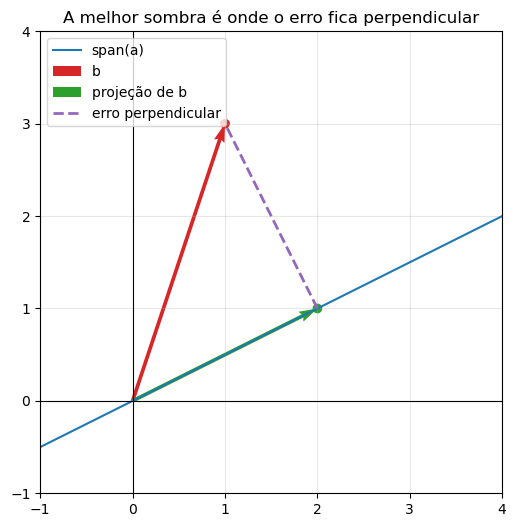

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
t = np.linspace(-0.5, 2.0, 100)
reta = np.outer(t, a_dir)

ax.plot(reta[:, 0], reta[:, 1], color='tab:blue', label='span(a)')
ax.quiver(0, 0, b_vec[0], b_vec[1], angles='xy', scale_units='xy', scale=1,
          color='tab:red', width=0.008, label='b')
ax.quiver(0, 0, proj[0], proj[1], angles='xy', scale_units='xy', scale=1,
          color='tab:green', width=0.008, label='projeção de b')
ax.plot([proj[0], b_vec[0]], [proj[1], b_vec[1]], '--', color='tab:purple',
        linewidth=2, label='erro perpendicular')

ax.scatter([b_vec[0], proj[0]], [b_vec[1], proj[1]], color=['tab:red', 'tab:green'])
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.set_title('A melhor sombra é onde o erro fica perpendicular')
plt.show()


In [14]:
# =============================================================================
#  10) (BÔNUS) PRODUTO VETORIAL — em 3D, gera um vetor PERPENDICULAR aos dois,
#      com tamanho = área do paralelogramo. (Enriquecimento, não núcleo de ML.)
# =============================================================================
secao("10) (bônus) PRODUTO VETORIAL — vetor perpendicular aos dois; tamanho = área")

p = np.array([2, 1, 3])
q = np.array([0, 4, 1])
pxq = np.cross(p, q)

print("p =", p, "  q =", q)
print("p × q =", pxq)
print("(p×q)·p =", pxq @ p, " e  (p×q)·q =", pxq @ q,
      " -> ambos ZERO: o resultado é perpendicular a p E a q (invariante que valida a conta)")





10) (bônus) PRODUTO VETORIAL — vetor perpendicular aos dois; tamanho = área
p = [2 1 3]   q = [0 4 1]
p × q = [-11  -2   8]
(p×q)·p = 0  e  (p×q)·q = 0  -> ambos ZERO: o resultado é perpendicular a p E a q (invariante que valida a conta)


In [15]:
# =============================================================================
#  11) AUTOVALORES e AUTOVETORES — a direção que a transformação SÓ ESTICA.
#      Av = λv. E o clímax: PCA É autovetor da matriz de covariância.
# =============================================================================
secao("11) AUTOVALORES e AUTOVETORES — Av = λv; e o PCA é isto por baixo")

# Uma transformação que estica na horizontal por 3 e deixa a vertical igual.
M = np.array([[3, 0],
              [0, 1]])

valores, vetores = np.linalg.eig(M)   # λ's e v's tais que M v = λ v
print("M =\n", M)
print("autovalores λ =", valores, " (fatores de esticamento)")
print("autovetores (colunas) =\n", vetores)

# Verificando a definição Av = λv na prática, para o 1º autovetor:
v0 = vetores[:, 0]
lam0 = valores[0]
print(f"\nTeste da definição no 1º autovetor:")
print("  M @ v =", M @ v0, "   λ * v =", lam0 * v0,
      "  -> iguais: M só ESCALOU v (não girou) — é isso que faz dele autovetor")

# --- O clímax: PCA = autovetores da matriz de COVARIÂNCIA ---
print("\n--- PCA em ciência de dados = autovetores da covariância ---")
rng = np.random.default_rng(0)
# Dados 2D correlacionados (uma nuvem alongada numa diagonal):
base = rng.normal(size=(300, 2))
dados = base @ np.array([[3.0, 1.0],
                         [1.0, 1.0]])      # estica/mistura pra criar correlação

cov = np.cov(dados, rowvar=False)          # matriz de covariância (SIMÉTRICA!)
lam, V = np.linalg.eigh(cov)               # eigh: pra matrizes simétricas
ordem = np.argsort(lam)[::-1]              # maior variância primeiro
lam, V = lam[ordem], V[:, ordem]

print("covariância é simétrica?", np.allclose(cov, cov.T),
      " -> por isso seus autovetores são ORTOGONAIS entre si (conecta com a seção 8)")
print("autovalores (variância em cada direção) =", lam)
print("componentes principais (autovetores, colunas) =\n", V)
print("são ortogonais entre si? (v1ᵀv2 ≈ 0):", round(V[:, 0] @ V[:, 1], 6))
print("\nÉ ISSO que sklearn.decomposition.PCA calcula: os autovetores da")
print("covariância = as direções de maior variância. Reduzir dimensão = ficar")
print("com os autovetores de maior autovalor e descartar o resto.")





11) AUTOVALORES e AUTOVETORES — Av = λv; e o PCA é isto por baixo
M =
 [[3 0]
 [0 1]]
autovalores λ = [3. 1.]  (fatores de esticamento)
autovetores (colunas) =
 [[1. 0.]
 [0. 1.]]

Teste da definição no 1º autovetor:
  M @ v = [3. 0.]    λ * v = [3. 0.]   -> iguais: M só ESCALOU v (não girou) — é isso que faz dele autovetor

--- PCA em ciência de dados = autovetores da covariância ---
covariância é simétrica? True  -> por isso seus autovetores são ORTOGONAIS entre si (conecta com a seção 8)
autovalores (variância em cada direção) = [11.841  0.333]
componentes principais (autovetores, colunas) =
 [[-0.924  0.383]
 [-0.383 -0.924]]
são ortogonais entre si? (v1ᵀv2 ≈ 0): 0.0

É ISSO que sklearn.decomposition.PCA calcula: os autovetores da
covariância = as direções de maior variância. Reduzir dimensão = ficar
com os autovetores de maior autovalor e descartar o resto.


### Gráfico — PCA: direção de maior variância


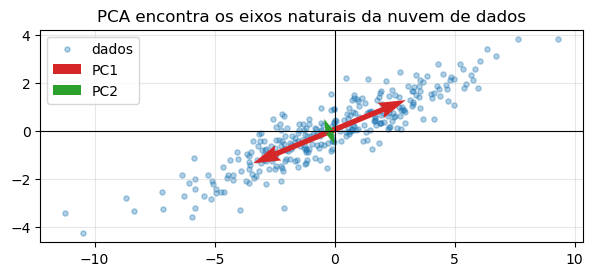

In [16]:
media = dados.mean(axis=0)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(dados[:, 0], dados[:, 1], s=14, alpha=0.35, color='tab:blue', label='dados')

for k, cor, nome in [(0, 'tab:red', 'PC1'), (1, 'tab:green', 'PC2')]:
    direcao = V[:, k] * np.sqrt(lam[k])
    ax.quiver(media[0], media[1], direcao[0], direcao[1],
              angles='xy', scale_units='xy', scale=1, color=cor, width=0.01, label=nome)
    ax.quiver(media[0], media[1], -direcao[0], -direcao[1],
              angles='xy', scale_units='xy', scale=1, color=cor, width=0.01)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.set_title('PCA encontra os eixos naturais da nuvem de dados')
plt.show()


In [17]:
# =============================================================================
#  FECHAMENTO — o fio que costura tudo
# =============================================================================
secao("FIO CONDUTOR — como tudo se conecta")
print("""
  transformação (matriz move o espaço)
     -> multiplicação = compor transformações
     -> determinante = quanto a área escala; 0 = colapso
     -> posto/inversa: posto cheio <=> det!=0 <=> invertível
     -> transposta espelha (e 'deita' vetores pro produto interno)
     -> produto interno = alinhamento/sobreposição
     -> ortogonalidade = sobreposição zero = informação independente
     -> PROJEÇÃO = achar a sombra; erro perpendicular; Xᵀe=0 => XᵀXŵ=Xᵀb = REGRESSÃO
     -> autovetores = direções preservadas; covariância simétrica => PCA

  Uma história só. Cada peça é a anterior vista de outro ângulo.
""")


FIO CONDUTOR — como tudo se conecta

  transformação (matriz move o espaço)
     -> multiplicação = compor transformações
     -> determinante = quanto a área escala; 0 = colapso
     -> posto/inversa: posto cheio <=> det!=0 <=> invertível
     -> transposta espelha (e 'deita' vetores pro produto interno)
     -> produto interno = alinhamento/sobreposição
     -> ortogonalidade = sobreposição zero = informação independente
     -> PROJEÇÃO = achar a sombra; erro perpendicular; Xᵀe=0 => XᵀXŵ=Xᵀb = REGRESSÃO
     -> autovetores = direções preservadas; covariância simétrica => PCA

  Uma história só. Cada peça é a anterior vista de outro ângulo.

